In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn.functional as F
import json
import numpy as np
import matplotlib.pyplot as plt
import random

# Data Paths
SHARED_ROOT   = "/content/drive/Shared drives/NPB 136 -- EYEBROW PIERCINGS"
STORAGE_FOLDER = os.path.join(SHARED_ROOT, "Project File Storage")
TENSOR_FOLDER  = os.path.join(STORAGE_FOLDER, "Tensors")

meta = json.load(open(os.path.join(TENSOR_FOLDER, "metadata.json")))

# Build lookup by patient
from collections import defaultdict
by_patient = defaultdict(list)
for entry in meta:
    patient = entry["patient_code"].split("/")[2].rsplit("_", 1)[0]
    by_patient[patient].append(entry)

pd_patients = sorted([p for p in by_patient if p.startswith("PD")], key=lambda x: int(x[2:]))
hc_patients = sorted([p for p in by_patient if p.startswith("HC")], key=lambda x: int(x[2:]))

print(f"PD patients: {pd_patients}")
print(f"HC patients: {hc_patients}")
print(f"Total samples: {len(meta)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PD patients: ['PD1', 'PD2', 'PD3', 'PD4', 'PD5', 'PD6', 'PD7', 'PD8', 'PD9', 'PD10', 'PD11', 'PD12', 'PD13', 'PD14']
HC patients: ['HC1', 'HC2', 'HC3', 'HC4', 'HC5', 'HC6', 'HC7', 'HC8', 'HC9', 'HC10', 'HC11', 'HC12', 'HC13']
Total samples: 727


In [10]:
CHANNEL_NAMES = ["Cell Stain (MAP2)", "α-Synuclein (ps129)"]
CMAPS         = ["Blues", "Reds"]
#CMAPS         = ["hot", "hot"]


def load_raw(entry):
    """Load tensor as-is → (2, 600, 600) float32"""
    t = torch.load(os.path.join(TENSOR_FOLDER, entry["file"]), weights_only=True)
    return t.float()  # (2, 600, 600)

def resize_tensor(t, size=384):
    """Resize (2, 600, 600) → (2, size, size)"""
    x = t.unsqueeze(1)  # (2, 1, 600, 600)
    x = F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
    return x.squeeze(1)  # (2, size, size)

def normalize_tensor(t):
    """Per-channel z-score normalization"""
    mean = t.mean(dim=[1, 2], keepdim=True)
    std  = t.std(dim=[1, 2],  keepdim=True).clamp(min=1e-8)
    return (t - mean) / std

def to_displayable(t):
    """Scale any tensor to [0,1] for imshow"""
    t = t.numpy()
    mn, mx = np.percentile(t, 2), np.percentile(t, 98)
    return np.clip((t - mn) / (mx - mn + 1e-8), 0, 1)

def visualize_entry(entry, title_prefix=""):
    """
    Show one sample three ways:
      Col 1-2: raw (no resize)
      Col 3-4: resized to 384x384
      Col 5-6: resized + normalized
    Rows = channels (MAP2, α-syn)
    """
    raw     = load_raw(entry)                        # (2, 600, 600)
    resized = resize_tensor(raw)                     # (2, 384, 384)
    normed  = normalize_tensor(resized)              # (2, 384, 384)

    patient  = entry["patient_code"].split("/")[2].rsplit("_", 1)[0]
    condition = "PD" if entry["label"] == 1 else "HC"

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(
        f"{title_prefix}  [{condition}] {patient} — {entry['file']}\n"
        f"Raw: {tuple(raw.shape)}  |  Resized: {tuple(resized.shape)}",
        fontsize=13, fontweight="bold", y=1.01
    )

    col_titles = ["Raw (600×600)", "Resized (384×384)", "Resized + Normalized"]

    for ch in range(2):
        imgs = [raw[ch], resized[ch], normed[ch]]
        for col, img in enumerate(imgs):
            ax  = axes[ch, col]
            arr = to_displayable(img)
            im  = ax.imshow(arr, cmap=CMAPS[ch], vmin=0, vmax=1)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_title(f"{col_titles[col]}\n{CHANNEL_NAMES[ch]}", fontsize=10)
            ax.axis("off")

            # Pixel stats
            raw_arr = img.numpy()
            ax.set_xlabel(
                f"min={raw_arr.min():.3f}  max={raw_arr.max():.3f}  "
                f"mean={raw_arr.mean():.3f}  std={raw_arr.std():.3f}",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

print("✓ Visualization functions loaded")

✓ Visualization functions loaded


Showing: [HC] HC2  →  Neurons_HC_HC2_0002.pt


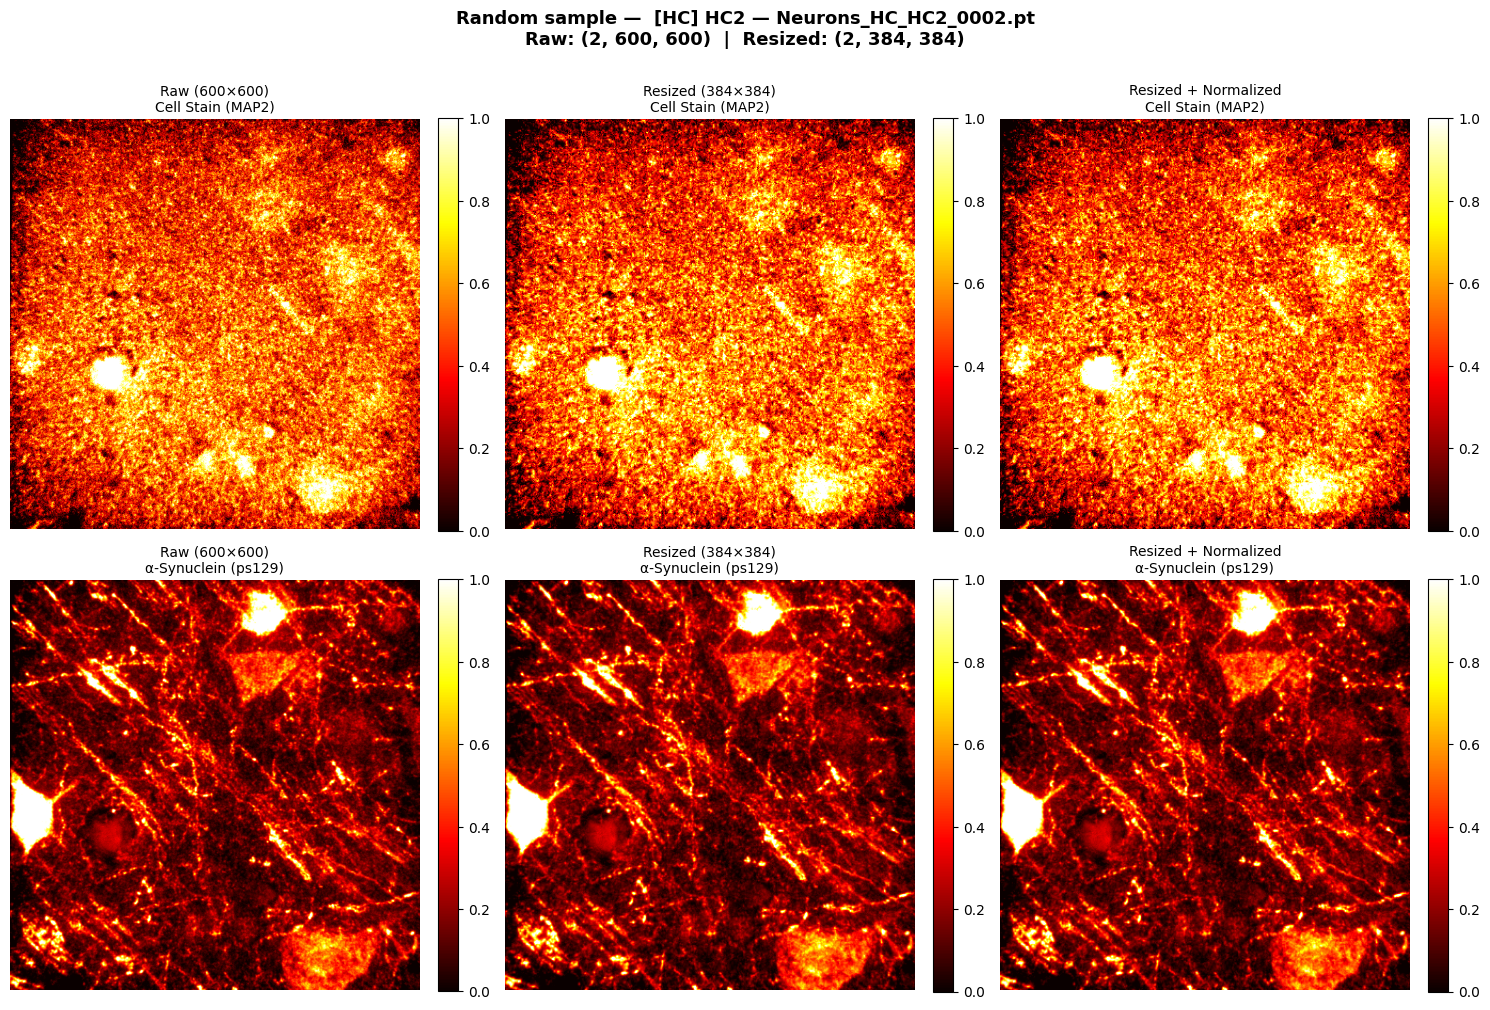

In [11]:
# Re-run this cell to see a new random patient each time

# Pick random condition and patient
condition = random.choice(["PD", "HC"])
patient   = random.choice(pd_patients if condition == "PD" else hc_patients)
entry     = random.choice(by_patient[patient])

print(f"Showing: [{condition}] {patient}  →  {entry['file']}")
visualize_entry(entry, title_prefix=f"Random sample —")

In [21]:
# Shows N images from the same patient to check intra-patient consistency
# Re-run for a different patient each time

condition  = random.choice(["PD", "HC"])
patient    = random.choice(pd_patients if condition == "PD" else hc_patients)
entries    = random.sample(by_patient[patient], min(4, len(by_patient[patient])))

print(f"Showing {len(entries)} samples from [{condition}] {patient}")

fig, axes = plt.subplots(len(entries), 2, figsize=(10, 4 * len(entries)))
fig.suptitle(f"[{condition}] {patient} — Intra-patient consistency\n(Normalized + Resized)",
             fontsize=13, fontweight="bold")

for row, entry in enumerate(entries):
    raw    = load_raw(entry)
    normed = normalize_tensor(resize_tensor(raw))
    sample = entry["file"].split("_")[-1].replace(".pt", "")

    for ch in range(2):
        ax  = axes[row, ch]
        arr = to_displayable(normed[ch])
        ax.imshow(arr, cmap=CMAPS[ch])
        ax.set_title(f"Sample {sample} — {CHANNEL_NAMES[ch]}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# Population-level overview — one random image per patient, one channel
# Change CHANNEL to 0 (MAP2) or 1 (α-syn)
CHANNEL = 1  # 0=MAP2, 1=α-synuclein

all_patients = pd_patients + hc_patients
n = len(all_patients)
ncols = 6
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
fig.suptitle(f"Population Overview — {CHANNEL_NAMES[CHANNEL]} (normalized)\n"
             f"▲=PD  ●=HC", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, patient in enumerate(all_patients):
    entry  = random.choice(by_patient[patient])
    raw    = load_raw(entry)
    normed = normalize_tensor(resize_tensor(raw))
    arr    = to_displayable(normed[CHANNEL])
    cond   = "PD" if entry["label"] == 1 else "HC"
    marker = "▲" if cond == "PD" else "●"

    axes[i].imshow(arr, cmap=CMAPS[CHANNEL])
    axes[i].set_title(f"{marker} {patient}", fontsize=8,
                      color="red" if cond == "PD" else "teal")
    axes[i].axis("off")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.